In [1]:
# =========================================
# 1. Import libraries
# =========================================

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

import numpy as np
import random
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

import os
from pathlib import Path

# 1. Set a master seed number
SEED = 42

# 2. Force Python and NumPy to use the seed
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)

# 3. Force TensorFlow / Keras to use the seed for weight initialization
tf.random.set_seed(SEED)

# 4. Optional: Force TensorFlow to operate deterministically
# Warning: This can slightly slow down your training speed, but ensures bit-for-bit replication
os.environ['TF_DETERMINISTIC_OPS'] = '1'

In [2]:
# check if all images have the same aspect ratio. Gemini recommends that all the images
# loaded into the neural network should have the same dimensions because the input layer
# will have a fixed number of input weights


from PIL import Image

# 1. Define your folder path
notebook_dir = Path.cwd()
train_image_folder = notebook_dir.parent / "train" / "train"

# 2. Collect all valid image paths
all_files = os.listdir(train_image_folder)
train_image_files = [f for f in all_files if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

# 3. Scan dimensions and compute aspect ratios
records = []

for file in train_image_files:
    file_path = os.path.join(train_image_folder, file)
    try:
        with Image.open(file_path) as img:
            width, height = img.size
            # Aspect ratio is width divided by height
            aspect_ratio = width / height
            
            records.append({
                'filename': file,
                'width': width,
                'height': height,
                'aspect_ratio': round(aspect_ratio, 4)
            })
    except Exception as e:
        print(f"Skipping damaged or unreadable file {file}: {e}")

# 4. Convert records into a scannable DataFrame
ratio_df = pd.DataFrame(records)

# Display the first few rows of your new summary table
print("--- Aspect Ratio Dataframe (Preview) ---")
print(ratio_df.head())
print("\n" + "="*40 + "\n")

# 5. Programmatically verify if all images are squares
# A perfect square has an aspect ratio of exactly 1.0
all_squares = (ratio_df['aspect_ratio'] == 1.0).all()

if all_squares:
    print("All images in the folder are squares.")
else:
    # Identify exactly which files are breaking the rule
    non_squares = ratio_df[ratio_df['aspect_ratio'] != 1.0]
    print(f"{len(non_squares)} images are not squares.")
    print("\nNon-square images:")
    print(non_squares[['filename', 'width', 'height', 'aspect_ratio']])

--- Aspect Ratio Dataframe (Preview) ---
        filename  width  height  aspect_ratio
0   apple_75.jpg    290     290        1.0000
1   apple_61.jpg    500     500        1.0000
2   apple_49.jpg    271     300        0.9033
3   orange_3.jpg    250     250        1.0000
4  orange_28.jpg    320     320        1.0000


179 images are not squares.

Non-square images:
          filename  width  height  aspect_ratio
2     apple_49.jpg    271     300        0.9033
5    banana_50.jpg    620     413        1.5012
6    orange_14.jpg    300     293        1.0239
7    banana_44.jpg    680     450        1.5111
8    banana_45.jpg    724     780        0.9282
..             ...    ...     ...           ...
215  banana_75.jpg    581     374        1.5535
216  orange_31.jpg   1300    1177        1.1045
217    apple_3.jpg   1000     708        1.4124
218   apple_44.jpg    337     335        1.0060
219   apple_50.jpg    300     227        1.3216

[179 rows x 4 columns]


In [3]:
# split training data into training and validation, perform one hot encoding

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder

# # 1. Re-verify files and create absolute paths
# all_files = os.listdir(image_folder)
# image_files = [f for f in all_files if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

labels = [file.split('_')[0] for file in train_image_files]
abs_paths = [os.path.join(train_image_folder, f) for f in train_image_files]

df = pd.DataFrame({
    'filepath': abs_paths,
    'label': labels
})

# 2. Stratified Split (80% Train, 20% Validation)
# We stratify directly on the text 'label' ('apple', 'banana', etc.)
train_df, val_df = train_test_split(
    df,
    test_size=0.2,
    random_state=42,
    stratify=df['label']
)

# 3. ONE-HOT ENCODING WITH SKLEARNER
# sparse_output=False ensures we get a normal NumPy array instead of a matrix format
encoder = OneHotEncoder(sparse_output=False)

# scikit-learn expects a 2D array, so we use [['label']] instead of ['label']
# We fit the encoder ONLY on the training data, then transform both sets
train_labels_one_hot = encoder.fit_transform(train_df[['label']])
val_labels_one_hot = encoder.transform(val_df[['label']])

print("OneHotEncoder implementation successful!")
print(f"Categories discovered by encoder: {encoder.categories_[0]}")
print(f"Sample encoded row shape: {train_labels_one_hot[0]}") # Displays [1. 0. 0.]

OneHotEncoder implementation successful!
Categories discovered by encoder: ['apple' 'banana' 'orange']
Sample encoded row shape: [0. 0. 1.]


In [4]:
# perform letterboxing on images. when an image is a long rectangle, it is padded with 
# black pixels then cropped to a square. 
# all images will be 150 x 150

import numpy as np
from PIL import Image, ImageOps

# Setting value to 150 means images will be resized and cropped to 150 x 150
IMG_SIZE = 128  

def process_single_letterbox(filepath):
    """Loads a raw image file, letterboxes it to a square, and normalizes pixels."""
    with Image.open(filepath) as img:
        img = img.convert('RGB') # Ensure it has 3 color channels (Red, Green, Blue)
        
        # 1. Shrink the image so its longest side is exactly IMG_SIZE pixels
        img.thumbnail((IMG_SIZE, IMG_SIZE), Image.Resampling.LANCZOS)
        
        # 2. Calculate how many black border pixels to add to fill out the square
        delta_w = IMG_SIZE - img.size[0]
        delta_h = IMG_SIZE - img.size[1]
        
        # Divide the padding evenly between top/bottom and left/right edges
        padding = (delta_w // 2, delta_h // 2, delta_w - (delta_w // 2), delta_h - (delta_h // 2))
        
        # Apply the borders
        letterboxed_img = ImageOps.expand(img, padding, fill=(0, 0, 0))
        
        # 3. Convert to a standard NumPy matrix and rescale pixel values to [0, 1] range
        return np.array(letterboxed_img, dtype=np.float32) / 255.0

# Run the fixed functions on your datasets
X_train = np.array([process_single_letterbox(path) for path in train_df['filepath']])
X_val = np.array([process_single_letterbox(path) for path in val_df['filepath']])

y_train = train_labels_one_hot
y_val = val_labels_one_hot

print(f"X_train array shape: {X_train.shape}")  # Will cleanly output: (num_images, 150, 150, 3)
print(f"y_train array shape: {y_train.shape}")  # Will cleanly output: (num_images, 3)

/Users/kwokheng/ml-tensorflow/.venv/lib/python3.13/site-packages/PIL/Image.py:1137: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


X_train array shape: (176, 128, 128, 3)
y_train array shape: (176, 3)


In [5]:
# # display sample images with distortion from RandAugment

# import matplotlib.pyplot as plt
# import tensorflow as tf
# from tensorflow.keras import layers

# NUM_OPS = 2
# FACTOR = 0.1
# # 1. Instantiate a standalone copy of your RandAugment layer for inspection
# # Use the exact same parameters you are testing in your model!
# inspect_aug = layers.RandAugment(num_ops=NUM_OPS, factor=FACTOR, value_range=(0.0, 1.0))

# # 2. Set up a grid to compare Original vs Augmented images
# # We will look at 4 random samples from your training data
# num_samples = 4
# fig, axes = plt.subplots(num_samples, 2, figsize=(8, 3 * num_samples))

# print("--- Visualizing RandAugment Distortions ---")

# for i in range(num_samples):
#     # Grab a real image from your processed X_train array
#     original_img = X_train[i]
    
#     # RandAugment expects a batch or a tensor, so we expand dimensions and apply it
#     # We set training=True to force the layer to actively distort the image
#     augmented_img = inspect_aug(tf.expand_dims(original_img, 0), training=True)[0].numpy()
    
#     # Plot Original Image (Left Column)
#     axes[i, 0].imshow(original_img)
#     axes[i, 0].set_title(f"Original {i+1}")
#     axes[i, 0].axis('off')
    
#     # Plot Augmented Image (Right Column)
#     axes[i, 1].imshow(augmented_img)
#     axes[i, 1].set_title(f"RandAugment (num_ops: {NUM_OPS}, Factor: {FACTOR})")
#     axes[i, 1].axis('off')

# plt.tight_layout()
# plt.show()

In [6]:
# build the CNN

from tensorflow import keras
from tensorflow.keras import layers

model = keras.Sequential([
    # 1. Input Layer: Matches our letterboxed dimensions
    keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3)),
    
    # 2. Augmentation Layer: Automatically active ONLY during training (.fit)
    # It scales its operations automatically because our input is already [0, 1]
    # layers.RandAugment(num_ops=NUM_OPS, factor=FACTOR, value_range=(0.0, 1.0)),
    
    # 3. Conv1 Layer Block
    layers.Conv2D(filters=16, kernel_size=(3, 3), padding="same", activation="relu"),
    layers.MaxPooling2D(pool_size=(2, 2)),
    
    # 4. Conv2 Layer Block
    layers.Conv2D(filters=32, kernel_size=(3, 3), padding="same", activation="relu"),
    layers.MaxPooling2D(pool_size=(2, 2)),

    # Add Dropout layer: Disable 30% of neurons
    # layers.Dropout(0.3), 
        
    # 5. Classifier Head
    layers.Flatten(),
    layers.Dense(units=128, activation="relu"),
    layers.Dense(units=3, activation="softmax") # 3 units for Apples, Bananas, Oranges
])

In [7]:
# Compile using categorical_crossentropy to match OneHotEncoder outputs!
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy', 
             keras.metrics.Precision(name='precision'), # Tracks false positives
             keras.metrics.Recall(name='recall')]        # Tracks false negatives
)
     
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     4,194,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,199,907 (16.02 MB)

 Trainable params: 4,199,907 (16.02 MB)

 Non-trainable params: 0 (0.00 B)

In [8]:
# apply early_stop to get best epoch for validation accuracy

early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss',     # Watch validation loss
    mode='min',                 # We want loss to go down
    patience=7,                 # If it doesn't beat 93.18% in 4 epochs, stop
    restore_best_weights=True   # Rewind to the absolute best epoch (Epoch 12)
)

In [9]:
# train the model
history = model.fit(
    X_train, 
    y_train,
    validation_data=(X_val, y_val),
        epochs=40,
        batch_size=16,
        callbacks=[early_stop]
)



Epoch 1/40
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - accuracy: 0.4773 - loss: 1.6897 - precision: 0.5000 - recall: 0.3011 - val_accuracy: 0.6364 - val_loss: 0.8426 - val_precision: 0.8125 - val_recall: 0.2955
Epoch 2/40
 3/11 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.7396 - loss: 0.7553 - precision: 0.8759 - recall: 0.5729

E0000 00:00:1779784997.858979  298903 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.6648 - loss: 0.7744 - precision: 0.7603 - recall: 0.5227 - val_accuracy: 0.6591 - val_loss: 0.6743 - val_precision: 0.6944 - val_recall: 0.5682
Epoch 3/40
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.8182 - loss: 0.4576 - precision: 0.8758 - recall: 0.7614 - val_accuracy: 0.7273 - val_loss: 0.4704 - val_precision: 0.7561 - val_recall: 0.7045
Epoch 4/40
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.8920 - loss: 0.2590 - precision: 0.9167 - recall: 0.8750 - val_accuracy: 0.8182 - val_loss: 0.3355 - val_precision: 0.8571 - val_recall: 0.8182
Epoch 5/40
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.9432 - loss: 0.1511 - precision: 0.9535 - recall: 0.9318 - val_accuracy: 0.8409 - val_loss: 0.3523 - val_precision: 0.8409 - val_recall: 0.8409
Epoch 6/40
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.9773 - loss: 0.1058 - precision: 0.9827 - recall: 0.9659 - val_accuracy: 0.8636 - val_loss: 0.3224 - val_preci

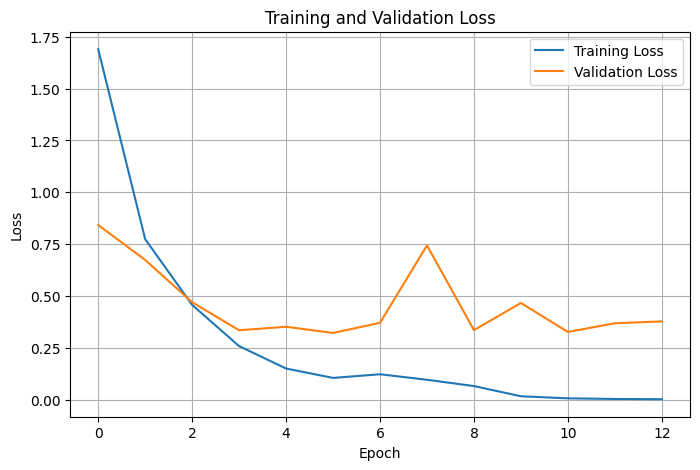

In [10]:
# =========================================
# 8. Plot training and validation loss
# =========================================

plt.figure(figsize=(8, 5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

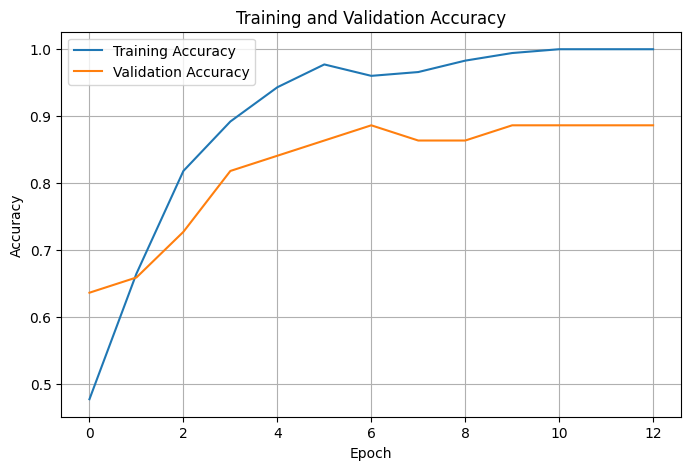

In [11]:
# =========================================
# 9. Plot training and validation accuracy
# =========================================

plt.figure(figsize=(8, 5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()

In [12]:
# load and preprocess test images

test_image_folder = notebook_dir.parent / "test" / "test"

# 2. Collect all valid image paths
all_files = os.listdir(test_image_folder)
test_image_files = [f for f in all_files if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

labels = [file.split('_')[0] for file in test_image_files]
test_abs_paths = [os.path.join(test_image_folder, f) for f in test_image_files]

# Update your test DataFrame with the correct paths
test_df = pd.DataFrame({
    'filepath': test_abs_paths,
    'label': labels
})

# Run letterboxing function on the test images
# This instantly outputs a clean, normalized array of shape (num_test_images, 150, 150, 3)
X_test = np.array([process_single_letterbox(path) for path in test_df['filepath']])

# One hot encoding for test labels
# Use .transform(), NOT .fit_transform()
# This ensures your test categories precisely match the column layout your model learned (apple, banana, orange).
y_test = encoder.transform(test_df[['label']])

print("--- Test Set Verification ---")
print(f"X_test pixel tensor shape: {X_test.shape}")
print(f"y_test one-hot matrix shape: {y_test.shape}")
print("=" * 50 + "\n")


--- Test Set Verification ---
X_test pixel tensor shape: (55, 128, 128, 3)
y_test one-hot matrix shape: (55, 3)



In [13]:
# =========================================
# 10. Evaluate the model on test data
# =========================================

test_loss, test_accuracy, test_precision, test_recall = model.evaluate(X_test, y_test)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)
print("Test Precision:", test_precision)
print("Test Recall:", test_recall)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9091 - loss: 0.3011 - precision: 0.9091 - recall: 0.9091
Test Loss: 0.30111148953437805
Test Accuracy: 0.9090909361839294
Test Precision: 0.9090909361839294
Test Recall: 0.9090909361839294


In [14]:
# =========================================
# 11. Make predictions
# =========================================

y_pred_prob = model.predict(X_test)

# Convert probabilities to class labels
y_pred = np.argmax(y_pred_prob, axis=1)

print("First 20 predicted labels:", y_pred[:20])
print("First 20 true labels:", y_test[:20])

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
First 20 predicted labels: [1 1 1 1 1 1 0 1 1 1 1 0 0 1 1 1 1 1 2 2]
First 20 true labels: [[0. 1. 0.]
 [0. 1. 0.]
 [0. 1. 0.]
 [0. 1. 0.]
 [0. 1. 0.]
 [0. 1. 0.]
 [1. 0. 0.]
 [0. 1. 0.]
 [0. 1. 0.]
 [0. 1. 0.]
 [0. 1. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [0. 1. 0.]
 [0. 1. 0.]
 [0. 1. 0.]
 [0. 1. 0.]
 [0. 1. 0.]
 [0. 0. 1.]
 [0. 0. 1.]]


In [15]:
# # =========================================
# # 12. Display sample predictions
# # =========================================

# plt.figure(figsize=(12, 6))

# for i in range(15):
#     plt.subplot(3, 5, i + 1)
#     plt.imshow(X_test[i].reshape(15, -1), cmap="gray")
#     plt.title(f"Pred: {y_pred[i]}, True: {y_test[i]}")
#     plt.axis("off")

# plt.tight_layout()
# plt.show()